# Byte-Pair Encoding (BPE) on Trigram Datasets (ACE)
This notebook loads trigram-frequency datasets from pre-computed `_functional.lab` files for three collections (*lastfm*, *suno*, *udio*),
runs a Byte-Pair Encoding algorithm to discover the most common adjacent token pairs, and visualises the top merged patterns.

In [10]:
import os
from collections import Counter

BASE_DIR = '/workspace/dataset'
COLLECTIONS = ['lastfm', 'suno', 'udio']

# ── Axis of Awesome ──
# Richards (2017) defines Axis progressions as cycling through the same 4 chords.
# Depending on key detection (major vs minor), the ACE labels differ:
#   Major key → vi–IV–I–V   (and cyclic perms)
#   Minor key → i–bVI–III–bVII  (and cyclic perms, hybrid notation from music21)
#   Minor key (rare variant) → i–bVI–bIII–bVII

AXIS_MAJOR = [
    ('I', 'V', 'vi', 'IV'),
    ('V', 'vi', 'IV', 'I'),
    ('vi', 'IV', 'I', 'V'),
    ('IV', 'I', 'V', 'vi'),
]
AXIS_MINOR = [
    ('i', 'bVI', 'III', 'bVII'),
    ('bVI', 'III', 'bVII', 'i'),
    ('III', 'bVII', 'i', 'bVI'),
    ('bVII', 'i', 'bVI', 'III'),
]
AXIS_MINOR2 = [
    ('i', 'bVI', 'bIII', 'bVII'),
    ('bVI', 'bIII', 'bVII', 'i'),
    ('bIII', 'bVII', 'i', 'bVI'),
    ('bVII', 'i', 'bVI', 'bIII'),
]

# All 4-chord axis permutations (union)
AXIS_PERMS = set()
for group in [AXIS_MAJOR, AXIS_MINOR, AXIS_MINOR2]:
    for p in group:
        AXIS_PERMS.add(p)

# The 4 axis chord sets (for "exclusively axis" check)
AXIS_CHORD_SETS = [
    {'I', 'V', 'vi', 'IV'},           # major
    {'i', 'bVI', 'III', 'bVII'},      # minor
    {'i', 'bVI', 'bIII', 'bVII'},     # minor variant
]

# All axis trigrams (3-chord windows inside the 4-chord cycle)
AXIS_TRIGRAMS = set()
for perm in AXIS_PERMS:
    extended = perm + perm  # wrap around
    for j in range(4):
        AXIS_TRIGRAMS.add(extended[j:j+3])

def parse_functional_lab(path):
    """Parse _functional.lab → list of chord labels."""
    labels = []
    with open(path) as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) >= 3 and parts[2] != 'N':
                labels.append(parts[2])
    return labels

def collapse_repeats(seq):
    if not seq:
        return []
    out = [seq[0]]
    for s in seq[1:]:
        if s != out[-1]:
            out.append(s)
    return out

def count_axis_trigrams(chords):
    """Count how many axis trigrams appear in the chord sequence."""
    count = 0
    for i in range(len(chords) - 2):
        tri = tuple(chords[i:i+3])
        if tri in AXIS_TRIGRAMS:
            count += 1
    return count

def is_exclusively_axis(chords):
    """Check if EVERY 4-chord window in the song is an axis permutation.
    This means the song never leaves the axis cycle.
    Requires at least 4 chords and every window to match."""
    if len(chords) < 4:
        return False
    n_windows = len(chords) - 3
    axis_windows = 0
    for i in range(n_windows):
        window = tuple(chords[i:i+4])
        if window in AXIS_PERMS:
            axis_windows += 1
    return axis_windows == n_windows

# ── Richards naming convention ──
def axis_form_name(perm):
    """Map a 4-chord perm to Richards' form names (C-form, a-form, F-form, G-form)."""
    if perm == ('I', 'V', 'vi', 'IV'):   return 'C-form (I–V–vi–IV)'
    if perm == ('vi', 'IV', 'I', 'V'):   return 'a-form (vi–IV–I–V)'
    if perm == ('IV', 'I', 'V', 'vi'):   return 'F-form (IV–I–V–vi)'
    if perm == ('V', 'vi', 'IV', 'I'):   return 'G-form (V–vi–IV–I)'
    if perm[0] == 'i':                    return f'a-form minor ({"–".join(perm)})'
    if perm[0] == 'III' or perm[0] == 'bIII': return f'C-form minor ({"–".join(perm)})'
    if perm[0] == 'bVI':                  return f'F-form minor ({"–".join(perm)})'
    if perm[0] == 'bVII':                 return f'G-form minor ({"–".join(perm)})'
    return '→'.join(perm)

# ── Scan every song ──
all_results = {}

for collection in COLLECTIONS:
    root = os.path.join(BASE_DIR, collection)
    n_songs = 0
    n_axis_songs = 0       # contains axis SOMEWHERE
    n_exclusive_axis = 0   # EXCLUSIVELY axis (every window is axis)
    n_major = 0
    n_minor = 0
    total_axis_trigrams = 0
    total_trigrams = 0
    axis_perm_counts = Counter()
    exclusive_examples = []  # store a few examples

    for song_id in sorted(os.listdir(root)):
        song_dir = os.path.join(root, song_id)
        if not os.path.isdir(song_dir):
            continue
        fp = os.path.join(song_dir, f'{song_id}_functional.lab')
        if not os.path.isfile(fp):
            continue

        chords = parse_functional_lab(fp)
        chords = collapse_repeats(chords)
        if len(chords) < 3:
            continue

        n_songs += 1
        n_tri = max(0, len(chords) - 2)
        total_trigrams += n_tri

        # Check for full 4-chord axis permutations
        found_major = False
        found_minor = False
        for i in range(len(chords) - 3):
            window = tuple(chords[i:i+4])
            if window in AXIS_PERMS:
                axis_perm_counts[window] += 1
                if window in [tuple(p) for p in AXIS_MAJOR]:
                    found_major = True
                else:
                    found_minor = True

        if found_major or found_minor:
            n_axis_songs += 1
        if found_major:
            n_major += 1
        if found_minor:
            n_minor += 1

        # Check if exclusively axis
        if is_exclusively_axis(chords):
            n_exclusive_axis += 1
            if len(exclusive_examples) < 5:
                unique_chords = list(dict.fromkeys(chords))  # preserve order, deduplicate
                exclusive_examples.append((song_id, len(chords), '–'.join(unique_chords[:8])))

        # Count axis trigrams
        total_axis_trigrams += count_axis_trigrams(chords)

    pct_songs = n_axis_songs / n_songs * 100 if n_songs else 0
    pct_excl = n_exclusive_axis / n_songs * 100 if n_songs else 0
    pct_tri = total_axis_trigrams / total_trigrams * 100 if total_trigrams else 0

    all_results[collection] = {
        'n_songs': n_songs, 'n_axis': n_axis_songs,
        'n_exclusive': n_exclusive_axis,
        'n_major': n_major, 'n_minor': n_minor,
        'pct_songs': pct_songs, 'pct_exclusive': pct_excl,
        'pct_tri': pct_tri,
        'perm_counts': axis_perm_counts,
        'exclusive_examples': exclusive_examples,
    }

# ── Main results table ──
print("=" * 120)
print(f"{'Collection':<10} {'Songs':>7} │ {'Somewhere':>10} {'%':>6} │ "
      f"{'Exclusive':>10} {'%':>6} │ {'Major':>6} {'Minor':>6} │ "
      f"{'AxisTri':>8} {'TotalTri':>10} {'%':>6}")
print("=" * 120)

for collection in COLLECTIONS:
    r = all_results[collection]
    print(f"{collection:<10} {r['n_songs']:>7,} │ "
          f"{r['n_axis']:>10,} {r['pct_songs']:>5.1f}% │ "
          f"{r['n_exclusive']:>10,} {r['pct_exclusive']:>5.1f}% │ "
          f"{r['n_major']:>6,} {r['n_minor']:>6,} │ "
          f"{r['pct_tri']:>14.2f}%")

# ── Breakdown by form (Richards-style) ──
print("\n" + "=" * 80)
print("Breakdown by Axis form (Richards 2017 naming)")
print("=" * 80)

for collection in COLLECTIONS:
    print(f"\n{collection.upper()}:")
    res = all_results[collection]
    for perm, cnt in res['perm_counts'].most_common():
        print(f"  {axis_form_name(perm):<45s}  {cnt:>6,} occurrences")

# ── Comparison with Richards ──
print("\n" + "=" * 80)
print("Comparison with Richards (2017): Billboard 1990-2016 ≈ 12% axis songs")
print("=" * 80)
print(f"\n  {'Collection':<10}  {'Somewhere':>10}  {'Exclusive':>10}")
print(f"  {'─'*40}")
for collection in COLLECTIONS:
    r = all_results[collection]
    print(f"  {collection:<10s}  {r['pct_songs']:>9.1f}%  {r['pct_exclusive']:>9.1f}%"
          f"   ({r['n_axis']:,} / {r['n_exclusive']:,} of {r['n_songs']:,} songs)"
          f"  [maj: {r['n_major']:,}, min: {r['n_minor']:,}]")
print(f"  {'─'*40}")
print(f"  {'Billboard':<10s}  {'≈12.0':>9}%  {'   –':>10}")

# ── Exclusive axis examples ──
print("\n" + "=" * 80)
print("Examples of EXCLUSIVELY axis songs (entire song = axis cycle)")
print("  Criterion: every 4-chord window after collapsing repeats is an axis perm")
print("=" * 80)
for collection in COLLECTIONS:
    r = all_results[collection]
    print(f"\n{collection.upper()} ({r['n_exclusive']:,} songs):")
    if r['exclusive_examples']:
        for sid, nchords, pattern in r['exclusive_examples']:
            print(f"  {sid:<30s}  {nchords:>3} chords  {pattern}")
    else:
        print(f"  (none)")

Collection   Songs │  Somewhere      % │  Exclusive      % │  Major  Minor │  AxisTri   TotalTri      %
lastfm      18,804 │      1,353   7.2% │          0   0.0% │    938    418 │           2.52%
suno        18,893 │      4,110  21.8% │         10   0.1% │  3,137    982 │           8.88%
udio        18,819 │      1,317   7.0% │          4   0.0% │    923    396 │           2.99%

Breakdown by Axis form (Richards 2017 naming)

LASTFM:
  C-form (I–V–vi–IV)                              2,396 occurrences
  F-form (IV–I–V–vi)                              2,351 occurrences
  a-form (vi–IV–I–V)                              2,299 occurrences
  G-form (V–vi–IV–I)                              2,155 occurrences
  a-form minor (i–bVI–III–bVII)                     629 occurrences
  C-form minor (III–bVII–i–bVI)                     615 occurrences
  F-form minor (bVI–III–bVII–i)                     598 occurrences
  G-form minor (bVII–i–bVI–III)                     554 occurrences
  G-form minor (b

In [1]:
import os, json, collections, math
from collections import Counter
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

# Filesystem layout
BASE_DIR = '/workspace/dataset'
COLLECTIONS = ['lastfm', 'suno', 'udio']

INIT_TOKEN = '<init>'
END_TOKEN  = '<end>'

print('Imports loaded')

Imports loaded


In [2]:
def parse_functional_lab(path: str) -> list:
    """Parse a _functional.lab file and return the list of functional labels."""
    labels = []
    with open(path, 'r', encoding='utf-8') as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            parts = line.split()
            if len(parts) < 3:
                continue
            label = parts[2]
            if label == 'N':
                continue
            labels.append(label)
    return labels


def load_chord_sequences(collection_name):
    """Return a list of full chord streams for one collection,
       reading Roman numerals directly from _functional.lab files."""
    seqs = []
    root = os.path.join(BASE_DIR, collection_name)

    for song_id in os.listdir(root):
        song_dir = os.path.join(root, song_id)
        if not os.path.isdir(song_dir):
            continue
        fp = os.path.join(song_dir, f'{song_id}_functional.lab')
        if not os.path.isfile(fp):
            continue

        tokens = parse_functional_lab(fp)
        if not tokens:
            continue

        seqs.append(tuple([INIT_TOKEN] + tokens + [END_TOKEN]))

    return seqs


def to_trigram_tokens(chord_seq):
    """Extract trigrams where all 3 chords are different."""
    trigram_list = []
    for i in range(len(chord_seq) - 2):
        tri = tuple(chord_seq[i:i+3])
        if len(set(tri)) == 3:
            trigram_list.append(tri)
    return tuple(trigram_list)


print('Data loading functions defined')

Data loading functions defined


In [3]:
# BPE core functions

def get_pair_frequencies(seq_counts):
    pair_freq = Counter()
    for tokens, cnt in seq_counts:
        for i in range(len(tokens) - 1):
            pair_freq[(tokens[i], tokens[i+1])] += cnt
    return pair_freq


def merge_pair(seq_counts, pair_to_merge, new_tok):
    a, b = pair_to_merge
    merged = []
    for tokens, cnt in seq_counts:
        new_tokens = []
        i = 0
        while i < len(tokens):
            if i < len(tokens) - 1 and tokens[i] == a and tokens[i+1] == b:
                new_tokens.append(new_tok)
                i += 2
            else:
                new_tokens.append(tokens[i])
                i += 1
        merged.append((tuple(new_tokens), cnt))
    return merged


def byte_pair_encoding(seq_counts, num_merges=150):
    merge_rules, merge_history = {}, []
    for m in range(num_merges):
        pf = get_pair_frequencies(seq_counts)
        if not pf:
            break
        (best_pair, freq) = pf.most_common(1)[0]
        new_tok = f'MERGE_{m}'
        merge_rules[new_tok] = best_pair
        merge_history.append((best_pair, freq))
        seq_counts = merge_pair(seq_counts, best_pair, new_tok)
    return merge_rules, merge_history


def expand_token(tok, rules):
    if tok not in rules:
        return [tok]
    a, b = rules[tok]
    return expand_token(a, rules) + expand_token(b, rules)


print('BPE functions defined')

BPE functions defined


In [4]:
# Run BPE on all collections

results = {}

for col in COLLECTIONS:
    print(f'\nProcessing {col}...')
    chord_streams = load_chord_sequences(col)
    print(f'  Loaded {len(chord_streams)} songs')

    # Convert to trigram sequences
    trigram_seqs = []
    for seq in chord_streams:
        tris = to_trigram_tokens(seq)
        if tris:
            trigram_seqs.append(tris)

    # Count unique trigram sequences
    seq_counter = Counter(trigram_seqs)
    seq_counts = list(seq_counter.items())
    print(f'  Unique trigram sequences: {len(seq_counts)}')

    # Run BPE
    rules, history = byte_pair_encoding(seq_counts, num_merges=150)
    results[col] = {'rules': rules, 'history': history}
    print(f'  BPE merges: {len(history)}')

print('\nBPE complete for all collections')


Processing lastfm...
  Loaded 18916 songs
  Unique trigram sequences: 18650
  BPE merges: 150

Processing suno...
  Loaded 18978 songs
  Unique trigram sequences: 18771
  BPE merges: 150

Processing udio...
  Loaded 19031 songs
  Unique trigram sequences: 18665
  BPE merges: 150

BPE complete for all collections


In [5]:
# Search for specific trigrams in BPE merge history

trigram_to_find = ('vi', 'IV', 'I')
for c in COLLECTIONS:
    for idx, ((a, b), freq) in enumerate(results[c]['history'], 1):
        if a == trigram_to_find or b == trigram_to_find:
            print(f'Found at index {idx} with frequency {freq} in {c}')

Found at index 5 with frequency 1898 in lastfm
Found at index 7 with frequency 1520 in lastfm
Found at index 57 with frequency 447 in lastfm
Found at index 2 with frequency 13419 in suno
Found at index 4 with frequency 4976 in suno
Found at index 70 with frequency 884 in suno
Found at index 4 with frequency 1671 in udio
Found at index 9 with frequency 1253 in udio


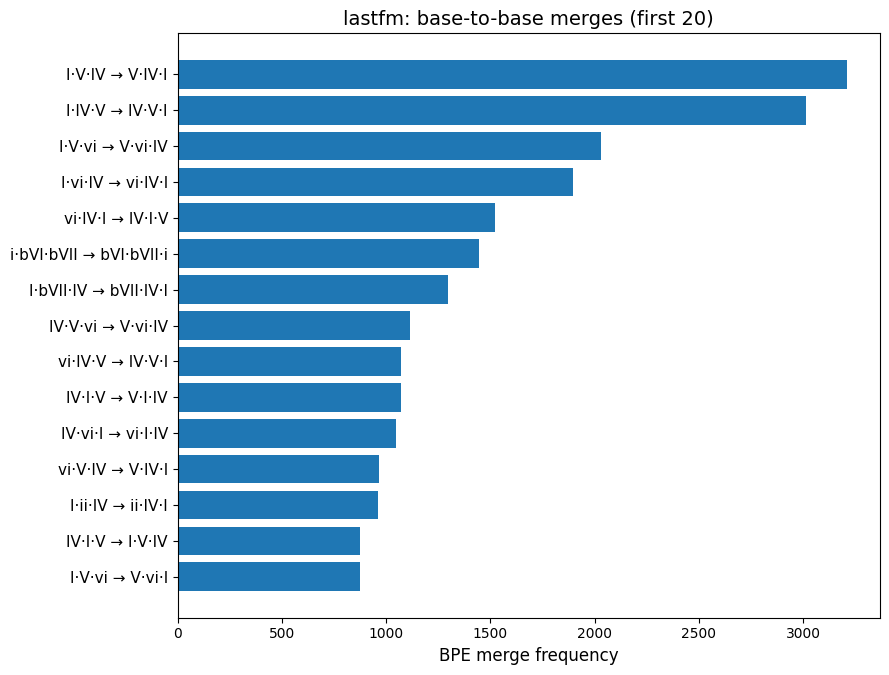

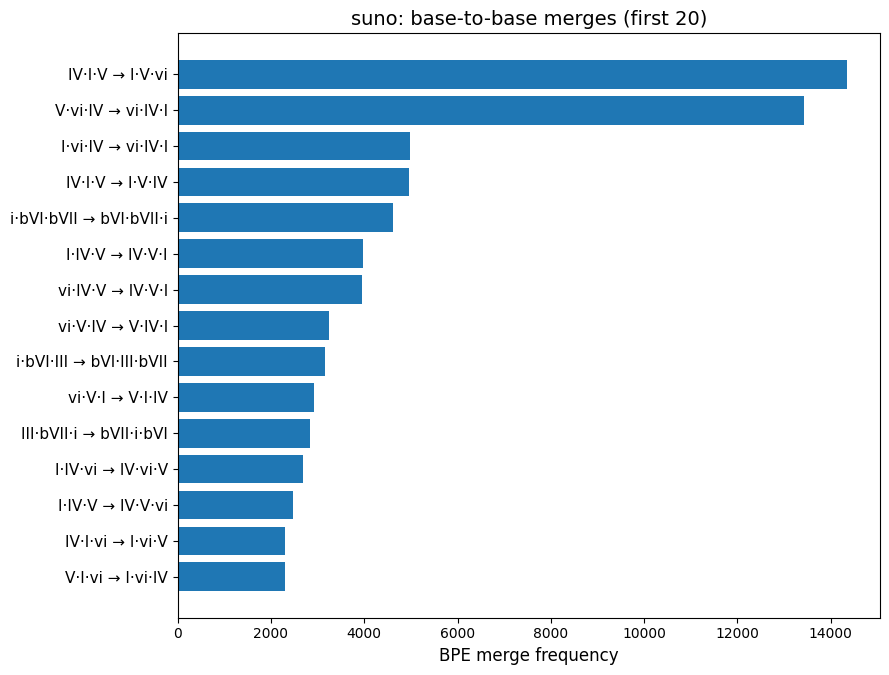

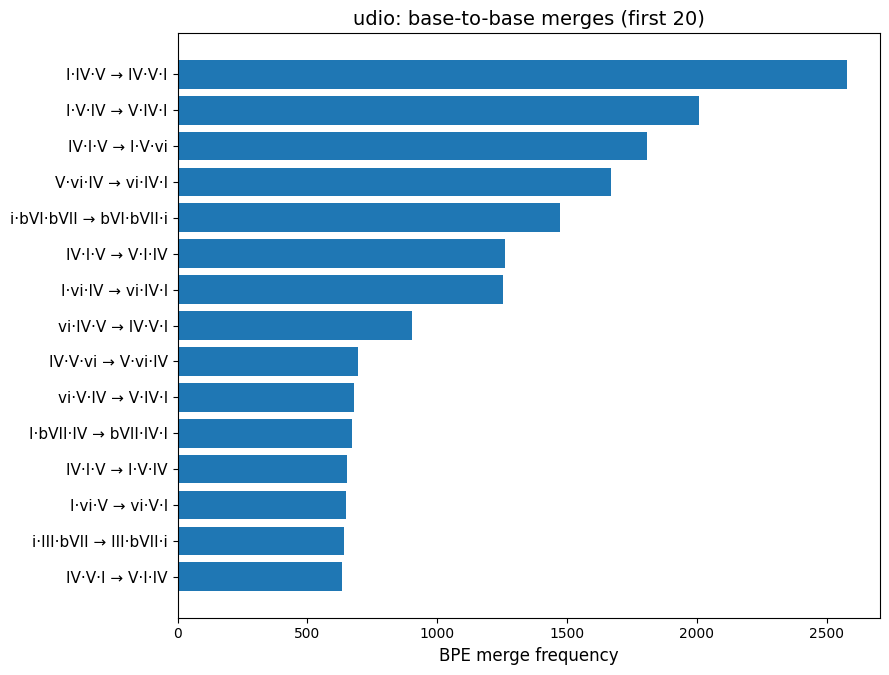

In [6]:
# Per-corpus plots of BPE base-to-base merges

def expand_base_trigrams(tok, rules):
    return expand_token(tok, rules)

def token_as_text_single(tok, rules):
    tris = expand_base_trigrams(tok, rules)
    if len(tris) != 1:
        return None
    return '\u00b7'.join(tris[0])

def _extract_freq(meta):
    if isinstance(meta, dict):
        return int(meta.get('freq', 0))
    return int(meta)

def collect_base_base_rows(res, top_k=20):
    rules = res['rules']
    hist = res['history'][:top_k] if top_k is not None else res['history']
    rows = []
    for (a, b), meta in hist:
        L = token_as_text_single(a, rules)
        R = token_as_text_single(b, rules)
        if L is None or R is None:
            continue
        rows.append((f'{L} \u2192 {R}', _extract_freq(meta)))
    rows.sort(key=lambda x: x[1], reverse=True)
    return rows

def plot_per_corpus_bars(results, collections, top_k=20):
    for corpus in collections:
        res = results[corpus]
        rows = collect_base_base_rows(res, top_k=top_k)
        if not rows:
            print(f'[{corpus}] No base-to-base merges in first {top_k}.')
            continue
        labels, vals = zip(*rows)
        y = np.arange(len(labels))
        fig_h = 0.35 * len(labels) + 1.6
        plt.figure(figsize=(9, fig_h))
        plt.barh(y, vals)
        plt.yticks(y, labels, fontsize=11)
        plt.xlabel('BPE merge frequency', fontsize=12)
        plt.title(f'{corpus}: base-to-base merges (first {top_k})', fontsize=14)
        plt.gca().invert_yaxis()
        plt.tight_layout()
        plt.show()

plot_per_corpus_bars(results, COLLECTIONS, top_k=20)

In [7]:
# Raw trigram frequencies analysis

def get_raw_trigram_frequencies(collection_name):
    print(f'\nAnalyzing {collection_name}...')
    chord_streams = load_chord_sequences(collection_name)
    print(f'   Loaded {len(chord_streams)} songs')
    all_trigrams = []
    for seq in chord_streams:
        trigrams = to_trigram_tokens(seq)
        all_trigrams.extend(trigrams)
    trigram_counts = Counter(all_trigrams)
    print(f'   Total trigrams: {len(all_trigrams)}')
    print(f'   Unique trigrams: {len(trigram_counts)}')
    return trigram_counts

raw_trigrams = {}
for col in COLLECTIONS:
    raw_trigrams[col] = get_raw_trigram_frequencies(col)

# Check specific important trigrams
target_trigrams = [
    ('vi', 'IV', 'I'),
    ('I', 'V', 'vi'),
    ('V', 'IV', 'I'),
    ('I', 'IV', 'V'),
    ('IV', 'I', 'V')
]

print(f'\nChecking specific trigrams that should be common:')
print(f'{"Trigram":<20} {"LastFM":<10} {"Suno":<10} {"Udio":<10}')
print('-' * 55)

for trigram in target_trigrams:
    freqs = [raw_trigrams[col].get(trigram, 0) for col in COLLECTIONS]
    trig_str = '\u00b7'.join(trigram)
    print(f'{trig_str:<20} {freqs[0]:<10} {freqs[1]:<10} {freqs[2]:<10}')

# Top 10 raw trigrams per collection
print(f'\nTop 10 raw trigrams per collection:')
for col in COLLECTIONS:
    print(f'\n{col.upper()}:')
    for trigram, freq in raw_trigrams[col].most_common(10):
        trig_str = '\u00b7'.join(trigram)
        print(f'  {trig_str:<25} {freq}')

# Check unique chord symbols
all_unique_chords = set()
for col in COLLECTIONS:
    for trigram in raw_trigrams[col].keys():
        all_unique_chords.update(trigram)

common_chords = ['I', 'IV', 'V', 'vi', 'ii', 'iii', 'bVI', 'bVII']
print(f'\nExpected chords found: {[c for c in common_chords if c in all_unique_chords]}')
print(f'Total unique chord symbols: {len(all_unique_chords)}')


Analyzing lastfm...
   Loaded 18916 songs
   Total trigrams: 903073
   Unique trigrams: 33970

Analyzing suno...
   Loaded 18978 songs
   Total trigrams: 1085240
   Unique trigrams: 20770

Analyzing udio...
   Loaded 19031 songs
   Total trigrams: 650804
   Unique trigrams: 29755

Checking specific trigrams that should be common:
Trigram              LastFM     Suno       Udio      
-------------------------------------------------------
vi·IV·I              5210       23047      3896      
I·V·vi               4419       21593      3691      
V·IV·I               6475       10171      4265      
I·IV·V               5925       8832       4928      
IV·I·V               9793       26725      7418      

Top 10 raw trigrams per collection:

LASTFM:
  IV·I·V                    9793
  IV·V·I                    7229
  V·I·IV                    7029
  V·IV·I                    6475
  I·IV·V                    5925
  I·V·IV                    5847
  vi·IV·I                   5210
  I·V·vi  

In [9]:
# ── Count unique SONGS per trigram pair — AXIS ONLY ──
# A pair is axis-related if at least one of its trigrams belongs to AXIS_TRIGRAMS
import os, numpy as np
from collections import Counter, defaultdict

BASE_DIR = '/workspace/dataset'
COLLECTIONS = ['lastfm', 'suno', 'udio']

# Reuse AXIS_TRIGRAMS and all_results from cell 2
print(f'Axis trigrams in filter: {len(AXIS_TRIGRAMS)}')
print(f'Axis trigrams: {sorted(["·".join(t) for t in AXIS_TRIGRAMS])}')

# Use actual song counts from cell 2 (not hardcoded)
total_songs = {col: all_results[col]['n_songs'] for col in COLLECTIONS}
print(f'Total songs: { {c: total_songs[c] for c in COLLECTIONS} }')

# ── Classify pair type ──
# A "full cycle" pair = both trigrams are axis AND together they form a 4-chord
# axis window (i.e., the pair represents two consecutive steps staying ON the cycle)
def pair_type(tri1, tri2):
    """Classify a trigram pair as CYCLE, ENTRY/EXIT, or PARTIAL."""
    t1_axis = tri1 in AXIS_TRIGRAMS
    t2_axis = tri2 in AXIS_TRIGRAMS
    if t1_axis and t2_axis:
        # Check if together they form a valid 4-chord axis segment:
        # tri1 = (a,b,c), tri2 = (b,c,d) → 4-chord window = (a,b,c,d)
        if tri1[1:] == tri2[:2]:  # overlapping correctly
            four = (tri1[0], tri1[1], tri1[2], tri2[2])
            if four in AXIS_PERMS:
                return 'CYCLE'  # both on axis AND continuing the cycle
        return 'AXIS↔AXIS'     # both axis trigrams but not consecutive in cycle
    elif t1_axis:
        return 'EXIT'           # leaves the axis
    else:
        return 'ENTRY'          # enters the axis

def parse_functional_lab(path):
    labels = []
    with open(path) as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) >= 3 and parts[2] != 'N':
                labels.append(parts[2])
    return labels

def collapse_repeats(seq):
    if not seq:
        return []
    out = [seq[0]]
    for s in seq[1:]:
        if s != out[-1]:
            out.append(s)
    return out

print('Counting unique songs per AXIS trigram pair...\n')

song_pair_counts = {}
pair_song_ids = {}

for col in COLLECTIONS:
    print(f'  Processing {col}...')
    root = os.path.join(BASE_DIR, col)
    pair_songs = defaultdict(set)

    for song_id in sorted(os.listdir(root)):
        song_dir = os.path.join(root, song_id)
        if not os.path.isdir(song_dir):
            continue
        fp = os.path.join(song_dir, f'{song_id}_functional.lab')
        if not os.path.isfile(fp):
            continue

        chords = parse_functional_lab(fp)
        chords = collapse_repeats(chords)
        if len(chords) < 4:
            continue

        trigrams = [tuple(chords[i:i+3]) for i in range(len(chords) - 2)]
        if len(trigrams) < 2:
            continue

        seen_pairs = set()
        for i in range(len(trigrams) - 1):
            t1, t2 = trigrams[i], trigrams[i+1]
            if t1 in AXIS_TRIGRAMS or t2 in AXIS_TRIGRAMS:
                seen_pairs.add((t1, t2))

        for pair in seen_pairs:
            pair_songs[pair].add(song_id)

    pair_song_ids[col] = pair_songs
    song_pair_counts[col] = Counter({p: len(s) for p, s in pair_songs.items()})

# ── Top-40 Suno-ranked axis pairs by unique songs ──
num = 40
suno_top = song_pair_counts['suno'].most_common(num)
table_pairs = [pair for pair, _ in suno_top]

print(f'\nTop {num} AXIS trigram pairs in Suno — UNIQUE SONGS')
print(f'{"Type":<10} {"Trigram Pair":<50} {"LastFM":>8} {"Suno":>8} {"Udio":>8}   {"LF%":>5} {"SU%":>5} {"UD%":>5}')
print('─' * 105)

freq_matrix = []
pair_labels = []

for (tri1, tri2), suno_cnt in suno_top:
    t1 = '·'.join(tri1)
    t2 = '·'.join(tri2)
    m1 = '★' if tri1 in AXIS_TRIGRAMS else ' '
    m2 = '★' if tri2 in AXIS_TRIGRAMS else ' '
    label = f'{m1}{t1} → {m2}{t2}'
    ptype = pair_type(tri1, tri2)
    lf = song_pair_counts['lastfm'].get((tri1, tri2), 0)
    ud = song_pair_counts['udio'].get((tri1, tri2), 0)
    lf_p = lf / total_songs['lastfm'] * 100
    su_p = suno_cnt / total_songs['suno'] * 100
    ud_p = ud / total_songs['udio'] * 100
    print(f'{ptype:<10} {label:<50} {lf:>8,} {suno_cnt:>8,} {ud:>8,}   {lf_p:>4.1f}% {su_p:>4.1f}% {ud_p:>4.1f}%')
    freq_matrix.append([lf, suno_cnt, ud])
    pair_labels.append(label)

freq_mat = np.array(freq_matrix)

# ── Summary by pair type ──
print(f'\n{"─"*105}')
print(f'\nBreakdown by pair type (unique songs union):')
type_songs = {col: {} for col in COLLECTIONS}
for ptype_label in ['CYCLE', 'EXIT', 'ENTRY', 'AXIS↔AXIS']:
    for col in COLLECTIONS:
        union = set()
        for (tri1, tri2), _ in suno_top:
            if pair_type(tri1, tri2) == ptype_label:
                union |= pair_song_ids[col].get((tri1, tri2), set())
        type_songs[col][ptype_label] = union

    counts = [len(type_songs[col][ptype_label]) for col in COLLECTIONS]
    pcts = [c / total_songs[col] * 100 for c, col in zip(counts, COLLECTIONS)]
    n_pairs = sum(1 for (t1, t2), _ in suno_top if pair_type(t1, t2) == ptype_label)
    print(f'  {ptype_label:<12} ({n_pairs:>2} pairs)  '
          f'LastFM {counts[0]:>5,} ({pcts[0]:.1f}%)  '
          f'Suno {counts[1]:>5,} ({pcts[1]:.1f}%)  '
          f'Udio {counts[2]:>5,} ({pcts[2]:.1f}%)')

# ── Overall union ──
print(f'\n  ALL axis-related pairs (union):')
for col in COLLECTIONS:
    union_songs = set()
    for pair in table_pairs:
        union_songs |= pair_song_ids[col].get(pair, set())
    n = len(union_songs)
    pct = n / total_songs[col] * 100
    print(f'  {col:<10s}  {n:>6,} unique songs in ≥1 of top-{num} axis pairs  '
          f'= {pct:.1f}% of {total_songs[col]:,} songs')

# Cross-check with cell 2's full axis count (4-chord windows)
print(f'\n  Cell 2 reference (full 4-chord axis, all perms):')
for col in COLLECTIONS:
    r = all_results[col]
    print(f'  {col:<10s}  {r["n_axis"]:>6,} axis songs = {r["pct_songs"]:.1f}%')

# ── Musical validation note ──
print(f'\n{"─"*105}')
print('PAIR TYPE LEGEND:')
print('  CYCLE     = Both trigrams ★ AND together form a consecutive 4-chord axis segment')
print('             (e.g., ★I·V·vi → ★V·vi·IV = staying ON the I–V–vi–IV cycle)')
print('  EXIT      = ★ axis trigram → non-axis (song LEAVES the axis)')
print('  ENTRY     = non-axis → ★ axis trigram (song ENTERS the axis)')
print('  AXIS↔AXIS = Both ★ but NOT consecutive in the same cycle rotation')

Axis trigrams in filter: 11
Axis trigrams: ['III·bVII·i', 'IV·I·V', 'I·V·vi', 'V·vi·IV', 'bIII·bVII·i', 'bVII·i·bVI', 'bVI·III·bVII', 'bVI·bIII·bVII', 'i·bVI·III', 'i·bVI·bIII', 'vi·IV·I']
Total songs: {'lastfm': 18804, 'suno': 18893, 'udio': 18819}
Counting unique songs per AXIS trigram pair...

  Processing lastfm...
  Processing suno...
  Processing udio...

Top 40 AXIS trigram pairs in Suno — UNIQUE SONGS
Type       Trigram Pair                                         LastFM     Suno     Udio     LF%   SU%   UD%
─────────────────────────────────────────────────────────────────────────────────────────────────────────
CYCLE      ★I·V·vi → ★V·vi·IV                                      562    2,410      536    3.0% 12.8%  2.8%
CYCLE      ★IV·I·V → ★I·V·vi                                       586    2,402      571    3.1% 12.7%  3.0%
CYCLE      ★V·vi·IV → ★vi·IV·I                                     524    2,333      534    2.8% 12.3%  2.8%
CYCLE      ★vi·IV·I → ★IV·I·V                

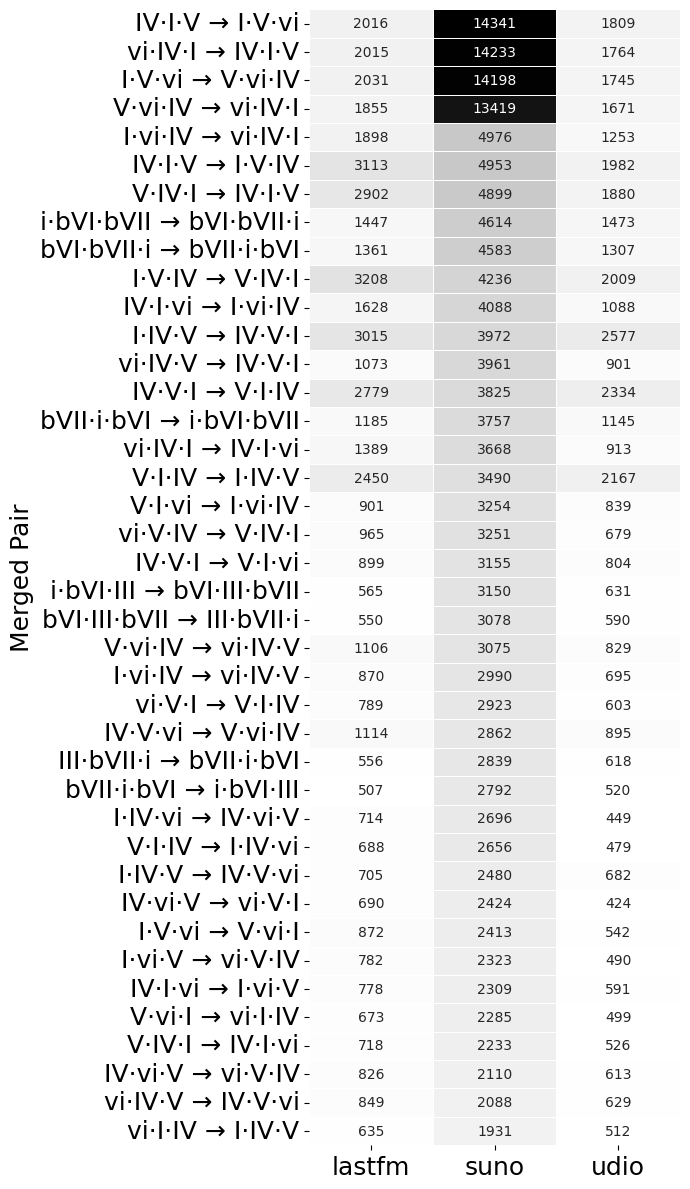

In [9]:
# Heatmap: Suno-ranked trigram pairs

text_size = 18
t_size = 18
col_width_in = 2
row_height_in = 0.25

fig_w = col_width_in * len(COLLECTIONS) + 1.0
fig_h = row_height_in * len(pair_labels_suno) + 2.0

plt.figure(figsize=(fig_w, fig_h))
sns.heatmap(
    freq_mat_suno,
    xticklabels=COLLECTIONS,
    yticklabels=pair_labels_suno,
    cmap='Greys',
    annot=True,
    fmt='.0f',
    linewidths=0.4,
    cbar=False
)
ax = plt.gca()
ax.set_xticklabels(ax.get_xticklabels(), fontsize=t_size, rotation=0)
ax.set_yticklabels(ax.get_yticklabels(), fontsize=t_size)
plt.ylabel('Merged Pair', fontsize=18)
plt.tight_layout()
plt.show()

Top 40 trigram pairs in Udio with cross-collection frequencies:
Trigram Pair                                       LastFM   Suno     Udio    
--------------------------------------------------------------------------------
I·IV·V → IV·V·I                                    3015     3972     2577    
IV·V·I → V·I·IV                                    2779     3825     2334    
V·I·IV → I·IV·V                                    2450     3490     2167    
I·V·IV → V·IV·I                                    3208     4236     2009    
IV·I·V → I·V·IV                                    3113     4953     1982    
V·IV·I → IV·I·V                                    2902     4899     1880    
IV·I·V → I·V·vi                                    2016     14341    1809    
vi·IV·I → IV·I·V                                   2015     14233    1764    
I·V·vi → V·vi·IV                                   2031     14198    1745    
V·vi·IV → vi·IV·I                                  1855     13419    1671  

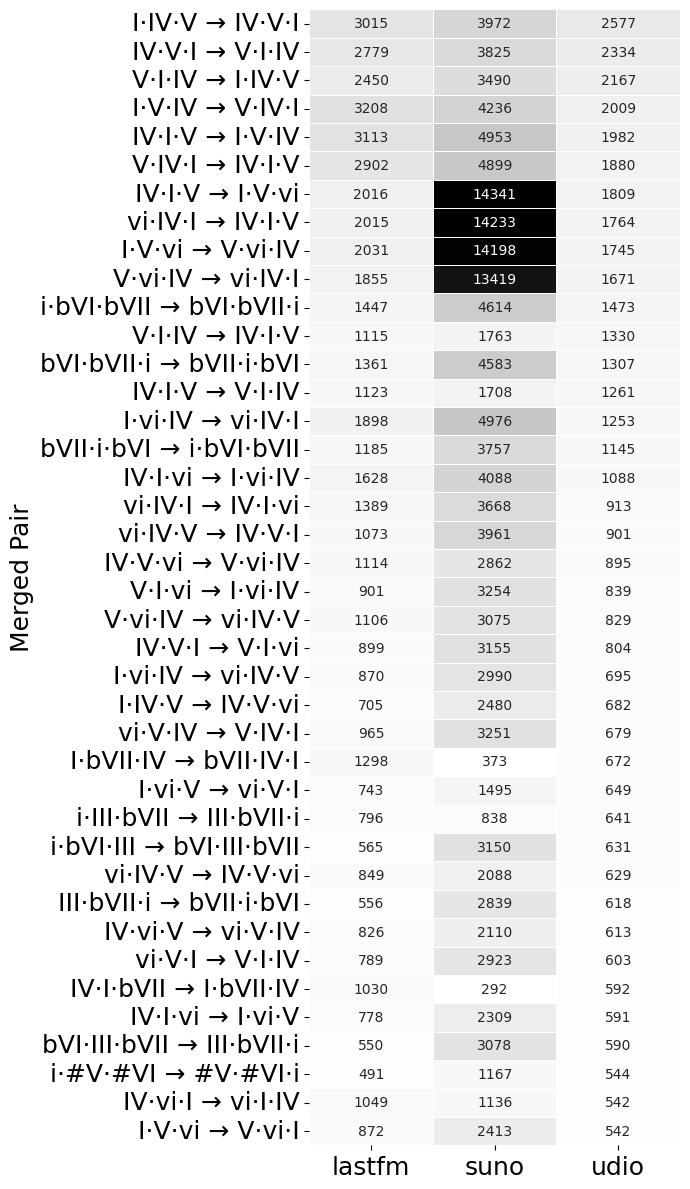

In [10]:
# Real trigram pair frequencies (Udio-ranked)

udio_top_pairs = real_pair_freqs['udio'].most_common(num)

print(f'Top {num} trigram pairs in Udio with cross-collection frequencies:')
print(f'{"Trigram Pair":<50} {"LastFM":<8} {"Suno":<8} {"Udio":<8}')
print('-' * 80)

freq_matrix_udio = []
pair_labels_udio = []

for (trigram1, trigram2), udio_freq in udio_top_pairs:
    tri1_str = '\u00b7'.join(trigram1)
    tri2_str = '\u00b7'.join(trigram2)
    pair_label = f'{tri1_str} \u2192 {tri2_str}'
    pair_key = (trigram1, trigram2)
    lastfm_freq = real_pair_freqs['lastfm'].get(pair_key, 0)
    suno_freq = real_pair_freqs['suno'].get(pair_key, 0)
    print(f'{pair_label:<50} {lastfm_freq:<8} {suno_freq:<8} {udio_freq:<8}')
    freq_matrix_udio.append([lastfm_freq, suno_freq, udio_freq])
    pair_labels_udio.append(pair_label)

freq_mat_udio = np.array(freq_matrix_udio)

# Cross-collection analysis
print(f'\nCross-collection analysis:')
non_zero_all = sum(1 for row in freq_mat_udio if all(f > 0 for f in row))
udio_only = sum(1 for row in freq_mat_udio if row[2] > 0 and row[0] == 0 and row[1] == 0)
print(f'Pairs in ALL 3 collections: {non_zero_all}')
print(f'Pairs in only Udio: {udio_only}')

for col1, col2 in pairs_list:
    idx1 = COLLECTIONS.index(col1)
    idx2 = COLLECTIONS.index(col2)
    corr = np.corrcoef(freq_mat_udio[:, idx1], freq_mat_udio[:, idx2])[0, 1]
    print(f'Correlation {col1}-{col2}: {corr:.3f}')

# Heatmap
fig_w = col_width_in * len(COLLECTIONS) + 1.0
fig_h = row_height_in * len(pair_labels_udio) + 2.0

plt.figure(figsize=(fig_w, fig_h))
sns.heatmap(
    freq_mat_udio,
    xticklabels=COLLECTIONS,
    yticklabels=pair_labels_udio,
    cmap='Greys',
    annot=True,
    fmt='.0f',
    linewidths=0.4,
    cbar=False
)
ax = plt.gca()
ax.set_xticklabels(ax.get_xticklabels(), fontsize=t_size, rotation=0)
ax.set_yticklabels(ax.get_yticklabels(), fontsize=t_size)
plt.ylabel('Merged Pair', fontsize=18)
plt.tight_layout()
plt.show()

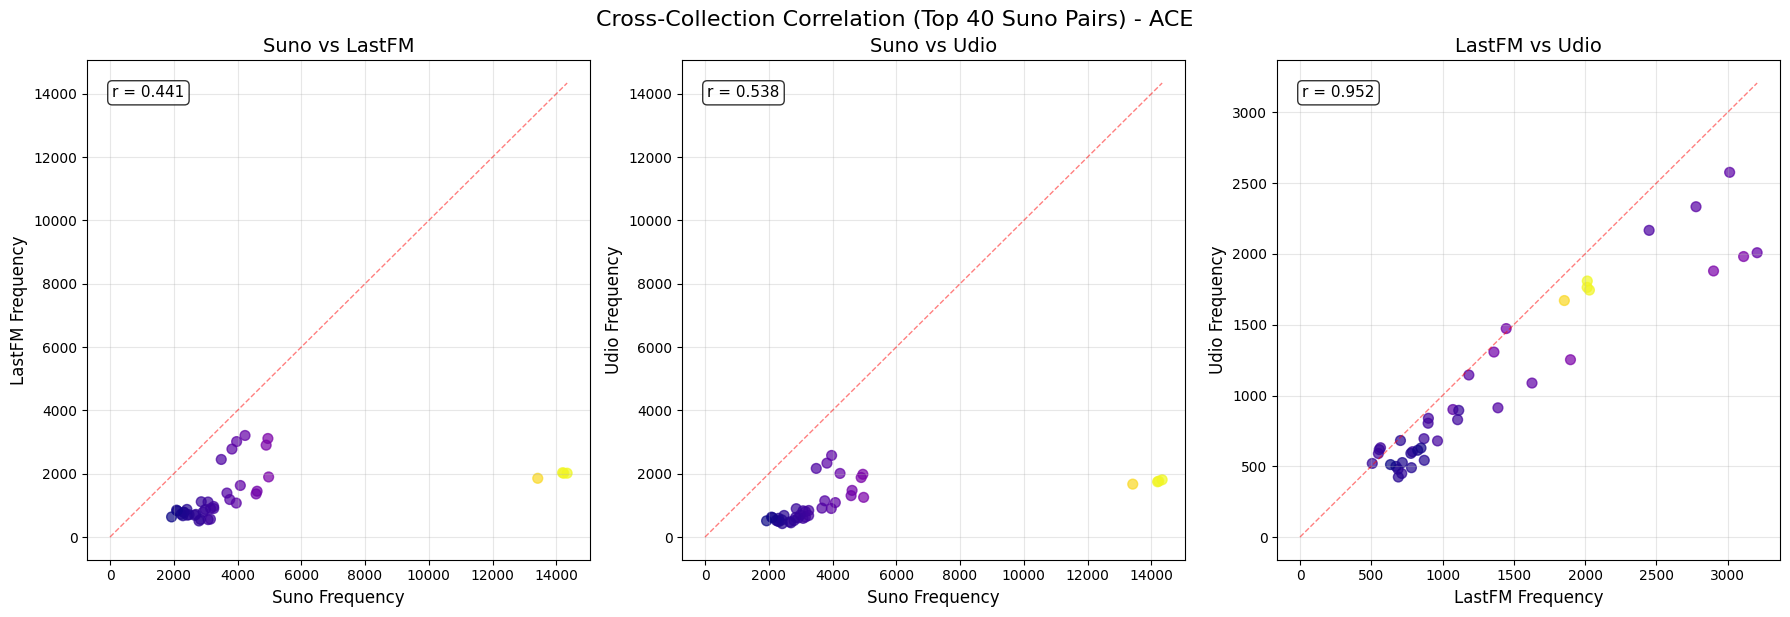


Most divergent patterns (high in one, low in others):
IV·I·V → I·V·vi                          | CV: 0.97 | Dominant in: suno (14341)
vi·IV·I → IV·I·V                         | CV: 0.97 | Dominant in: suno (14233)
I·V·vi → V·vi·IV                         | CV: 0.97 | Dominant in: suno (14198)
V·vi·IV → vi·IV·I                        | CV: 0.97 | Dominant in: suno (13419)
I·vi·IV → vi·IV·I                        | CV: 0.60 | Dominant in: suno (4976)
IV·I·V → I·V·IV                          | CV: 0.37 | Dominant in: suno (4953)
V·IV·I → IV·I·V                          | CV: 0.39 | Dominant in: suno (4899)
i·bVI·bVII → bVI·bVII·i                  | CV: 0.59 | Dominant in: suno (4614)
bVI·bVII·i → bVII·i·bVI                  | CV: 0.63 | Dominant in: suno (4583)
I·V·IV → V·IV·I                          | CV: 0.29 | Dominant in: suno (4236)

Perfect overlaps (similar frequencies across all collections):
IV·I·V → I·V·IV                          | LastFM: 3113, Suno: 4953, Udio: 1982
V·IV·I 

In [11]:
# Scatter plot: cross-collection correlation analysis

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

lastfm_freqs = freq_mat_suno[:, 0]
suno_freqs = freq_mat_suno[:, 1]
udio_freqs = freq_mat_suno[:, 2]

comparisons = [
    (suno_freqs, lastfm_freqs, 'Suno vs LastFM', 'Suno Frequency', 'LastFM Frequency'),
    (suno_freqs, udio_freqs, 'Suno vs Udio', 'Suno Frequency', 'Udio Frequency'),
    (lastfm_freqs, udio_freqs, 'LastFM vs Udio', 'LastFM Frequency', 'Udio Frequency')
]

for i, (x_data, y_data, title, xlabel, ylabel) in enumerate(comparisons):
    ax = axes[i]
    scatter = ax.scatter(x_data, y_data, alpha=0.7, s=50, c=suno_freqs, cmap='plasma')
    max_val = max(max(x_data), max(y_data))
    ax.plot([0, max_val], [0, max_val], 'r--', alpha=0.5, linewidth=1)
    ax.set_xlabel(xlabel, fontsize=12)
    ax.set_ylabel(ylabel, fontsize=12)
    ax.set_title(title, fontsize=14)
    ax.grid(True, alpha=0.3)
    correlation = np.corrcoef(x_data, y_data)[0, 1]
    ax.text(0.05, 0.95, f'r = {correlation:.3f}', transform=ax.transAxes,
            fontsize=11, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.suptitle(f'Cross-Collection Correlation (Top {num} Suno Pairs) - ACE', fontsize=16, y=1.02)
plt.show()

# Most divergent patterns
print('\nMost divergent patterns (high in one, low in others):')
for i, pair in enumerate(pair_labels_suno[:10]):
    lastfm, suno, udio = freq_mat_suno[i]
    freqs = [lastfm, suno, udio]
    if sum(freqs) > 0:
        cv = np.std(freqs) / np.mean(freqs)
        max_col = COLLECTIONS[np.argmax(freqs)]
        print(f'{pair:<40} | CV: {cv:.2f} | Dominant in: {max_col} ({max(freqs)})')

print('\nPerfect overlaps (similar frequencies across all collections):')
count = 0
for i, pair in enumerate(pair_labels_suno):
    lastfm, suno, udio = freq_mat_suno[i]
    if min(lastfm, suno, udio) > 50:
        cv = np.std([lastfm, suno, udio]) / np.mean([lastfm, suno, udio])
        if cv < 0.5:
            print(f'{pair:<40} | LastFM: {lastfm}, Suno: {suno}, Udio: {udio}')
            count += 1
            if count >= 5:
                break